# Анализ влияния Smart Bidding на выручку проекта AN-1941

[Отчёт здесь](https://docs.google.com/spreadsheets/d/13hE1TZrIgoeeHoLdgw0yD27nu2ml9NmcXiAWseYM-BU/edit?gid=361514793#gid=361514793)

__Цель анализа__

Оценить, повлияло ли внедрение Smart Bidding на:

общую выручку проекта,

и отделить эффект Smart Bidding от:

- сезонности,
- изменения структуры трафика (inhouse/resell),
- пользовательского оттока.

__Краткие выводы__

Общая просадка Января-Февраля относительно Ноября-Декабря составляет 19%, что нормально с исторической точки зрения. <br>Просадка равномерна как на инхаусе, так и на реселе.

Аномальный Январь объясняется жирным Декабрём + высоким оттоком, в Феврале картина стабилизируется.

Говоря о смарт-биддинге :

- отток с фичей ниже почти в 2 раза
- спенд юзеров со смартом стабилен в оба периода


Просадка проекта на 100% обусловлена юзерами, которые не используют фичу

## Импорт и запросы

In [32]:
import pandas as pd
import numpy as np
import os
from sqlalchemy import create_engine
import clickhouse_connect
import matplotlib.pyplot as plt

### Подключения

In [306]:
db_config = {
'host': 'dbro.clickadilla.com',
'port' : 3306,
'db' : 'clickadilla_db',
'user' : os.getenv('MYSQL_USER'),
'pass' : os.getenv('MYSQL_PASSWORD'),
}
 
# connection_string = "mysql+pymysql://<dbuser>:<pwd>@<server_ip>/<db_instance>"
connection_string = 'mysql+pymysql://{}:{}@{}/{}'.format(
    db_config['user'],
    db_config['pass'],
    db_config['host'],
    db_config['db'],
)

In [307]:
engine = create_engine(connection_string)

In [213]:
client = clickhouse_connect.get_client(
    host='109.206.161.22',
    port=8123,
    username='readonly',
    password=''
)

### Кол-во кампаний с фичей по форматам

In [84]:
query_1 = f'''
SELECT
    t.ad_format AS format,
    CONCAT(
    WEEKOFYEAR(t.created_at),
    ' (',
    DATE_FORMAT(
        DATE_SUB(t.created_at, INTERVAL WEEKDAY(t.created_at) DAY),
        '%%m-%%d'
    ),
    ')'
) AS week_label,
DATE_SUB(DATE(t.created_at), INTERVAL WEEKDAY(t.created_at) DAY) AS week_start,
COUNT(DISTINCT t.campaign_id) AS cnt_add_feature
FROM (
    SELECT
        a.auditable_id AS campaign_id,
        a.created_at,
        c.ad_format,
        CASE
            WHEN JSON_EXTRACT(a.new_values, '$.smart_bidding') IS NULL THEN NULL
            WHEN JSON_UNQUOTE(JSON_EXTRACT(a.new_values, '$.smart_bidding')) IN ('true','1') THEN 1
            WHEN JSON_UNQUOTE(JSON_EXTRACT(a.new_values, '$.smart_bidding')) IN ('false','0') THEN 0
            ELSE NULL
        END AS new_status
    FROM audits a
    JOIN campaigns c
        ON c.id = a.auditable_id
       AND c.ad_format IN ('popunder', 'in-page-ad', 'in-stream-ad')
    JOIN users u
        ON u.id = c.user_id
       AND u.email NOT LIKE '%%onlinesup%%'
    LEFT JOIN networks n
        ON n.user_id = u.id
    WHERE a.auditable_type LIKE '%%Campaign'
      AND a.event != 'deleted'
      AND n.user_id IS NULL
      AND (
          JSON_EXTRACT(a.new_values, '$.smart_bidding') IS NOT NULL
          OR JSON_EXTRACT(a.old_values, '$.smart_bidding') IS NOT NULL
      )
    HAVING new_status = 1
) AS t
GROUP BY
    FORMAT, week_label
ORDER BY
    week_start,
    format
'''

In [85]:
add_campaigns = pd.read_sql(query_1, engine)

In [86]:
add_campaigns

,format,week_label,week_start,cnt_add_feature
0,popunder,48 (11-24),2025-11-24,5
1,popunder,49 (12-01),2025-12-01,27
2,popunder,50 (12-08),2025-12-08,95
3,popunder,51 (12-15),2025-12-15,179
4,popunder,52 (12-22),2025-12-22,127
5,in-page-ad,52 (12-22),2025-12-22,7
6,popunder,1 (12-29),2025-12-29,81
7,in-page-ad,1 (12-29),2025-12-29,8
8,popunder,2 (01-05),2026-01-05,110
9,in-page-ad,2 (01-05),2026-01-05,5


In [104]:
df_plot = (
    add_campaigns.query('week_label != "9 (02-23)"')
    .pivot(index='week_start', columns='format', values='cnt_add_feature')
    .fillna(0)
    .sort_index()
)

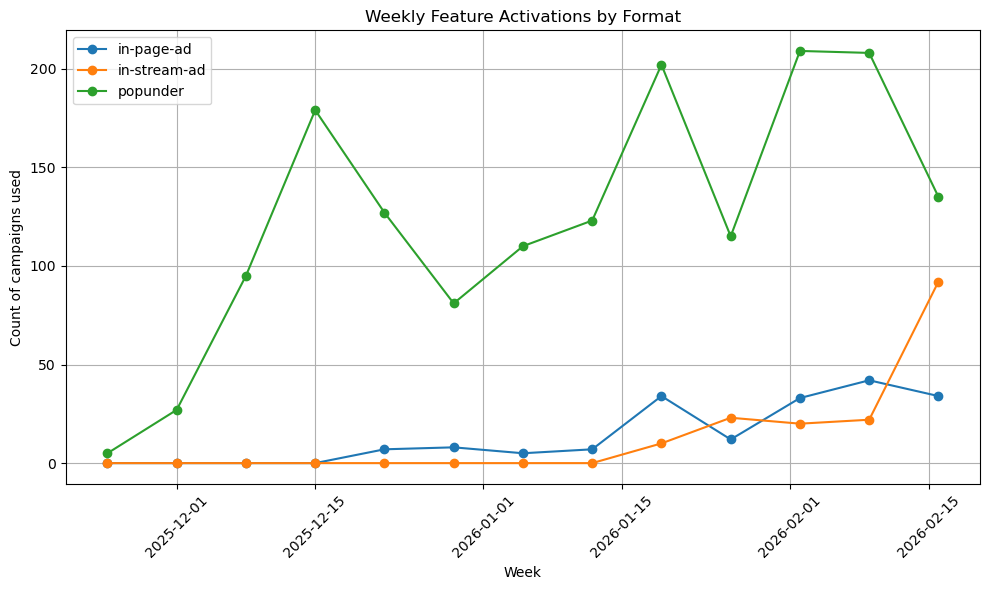

In [105]:
plt.figure(figsize=(10, 6))

for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col], marker='o', label=col)

plt.title('Weekly Feature Activations by Format')
plt.xlabel('Week')
plt.ylabel('Count of campaigns used')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

На попандере старт релиза фичи приходится на неделю 2025-11-24, инпейдж - 2025-12-22, видео - 2026-01-19.

Пик использования на попандере наблюдаем во вторую неделю Декабря, и затем после 3 недели Января
Инпейдж - 3 неделя Января, видео - 2 неделя Февраля

### % Просадки по форматам

In [110]:
query_form = f'''
SELECT
    CASE
        WHEN c.ad_format IN ('popunder', 'in-page-ad', 'in-stream-ad') THEN c.ad_format
        ELSE 'other'
    END AS format,
CONCAT(
    WEEKOFYEAR(cs.date),
    ' (',
    DATE_FORMAT(
        DATE_SUB(cs.date, INTERVAL WEEKDAY(cs.date) DAY),
        '%%m-%%d'
    ),
    ')'
) AS week_label,
WEEKOFYEAR(cs.date) AS week,
DATE_SUB(DATE(cs.date), INTERVAL WEEKDAY(cs.date) DAY) AS week_start,
    SUM(cs.cost) / 10000 AS spend
FROM campaign_statistics cs
JOIN campaigns c
    ON cs.campaign_id = c.id
JOIN users u
    ON u.id = c.user_id
   AND u.email NOT LIKE '%%onlinesup%%'
LEFT JOIN networks n
    ON n.user_id = c.user_id
WHERE cs.date >= '2025-10-27'
AND cs.date < '2026-02-23'
  AND n.user_id IS NULL
GROUP BY
    format,
    week_label
ORDER BY
    week_start, format
'''

In [111]:
spend_formats = pd.read_sql(query_form, engine)

In [136]:
spend_formats.head()

,format,week_label,week,week_start,spend
0,in-page-ad,44 (10-27),44,2025-10-27,16037.2025
1,in-stream-ad,44 (10-27),44,2025-10-27,15652.9266
2,other,44 (10-27),44,2025-10-27,4531.4547
3,popunder,44 (10-27),44,2025-10-27,59005.5519
4,in-page-ad,45 (11-03),45,2025-11-03,20861.4085


Берём водораздел в неделю запуска фичи (48 или 2025-11-24) и сравним средненедельные показатели до и после

In [117]:
before = spend_formats.query('week < 48 and week > 43')

In [127]:
after = spend_formats.query('week >= 48 or week < 9')

In [128]:
summary = before.groupby('format')['spend'].mean().reset_index().rename(columns={'spend':'avg_spend_before'}).merge(
after.groupby('format')['spend'].mean().reset_index().rename(columns={'spend':'avg_spend_after'}))

In [129]:
summary['delta'] = summary['avg_spend_after'] - summary['avg_spend_before']

In [130]:
summary['delta%'] = summary['delta'] / summary['avg_spend_before']

In [134]:
summary.round(2)

,format,avg_spend_before,avg_spend_after,delta,delta%
0,in-page-ad,19321.80,16289.10,-3032.71,-0.16
1,in-stream-ad,18161.46,13953.38,-4208.09,-0.23
2,other,4947.44,5918.44,971.00,0.20
3,popunder,65630.96,59612.86,-6018.10,-0.09


In [162]:
print('Средненедельный спенд в периоды до и после')
print(summary['avg_spend_before'].sum().round())
print(summary['avg_spend_after'].sum().round())

Средненедельный спенд в периоды до и после
108062.0
95774.0


In [163]:
round((summary['avg_spend_before'].sum() - summary['avg_spend_after'].sum()) / summary['avg_spend_before'].sum(), 2)

0.11

Если брать текущий подход (в качестве baseline месяца Ноябрь), то видим просадку по Попандеру 9%, по инпейджу - 16%, по видео - 23%, а так же прирост по другим форматам в 20%. (Если сравнивать Декабрь с Январём+Февралём, то там просадка по инпейджу достигала 30%)

По общей картине проекта в целом наблюдаем средненедельную просадку в 11%

Изучим динамику

In [137]:
spend_formats

,format,week_label,week,week_start,spend
0,in-page-ad,44 (10-27),44,2025-10-27,16037.2025
1,in-stream-ad,44 (10-27),44,2025-10-27,15652.9266
2,other,44 (10-27),44,2025-10-27,4531.4547
3,popunder,44 (10-27),44,2025-10-27,59005.5519
4,in-page-ad,45 (11-03),45,2025-11-03,20861.4085
...,...,...,...,...,...
63,popunder,7 (02-09),7,2026-02-09,50088.2127
64,in-page-ad,8 (02-16),8,2026-02-16,19492.9481
65,in-stream-ad,8 (02-16),8,2026-02-16,13064.4902
66,other,8 (02-16),8,2026-02-16,7901.5322


In [139]:
df_plot_spend = (
    spend_formats
    .pivot(index='week_start', columns='format', values='spend')
    .fillna(0)
    .sort_index()
)

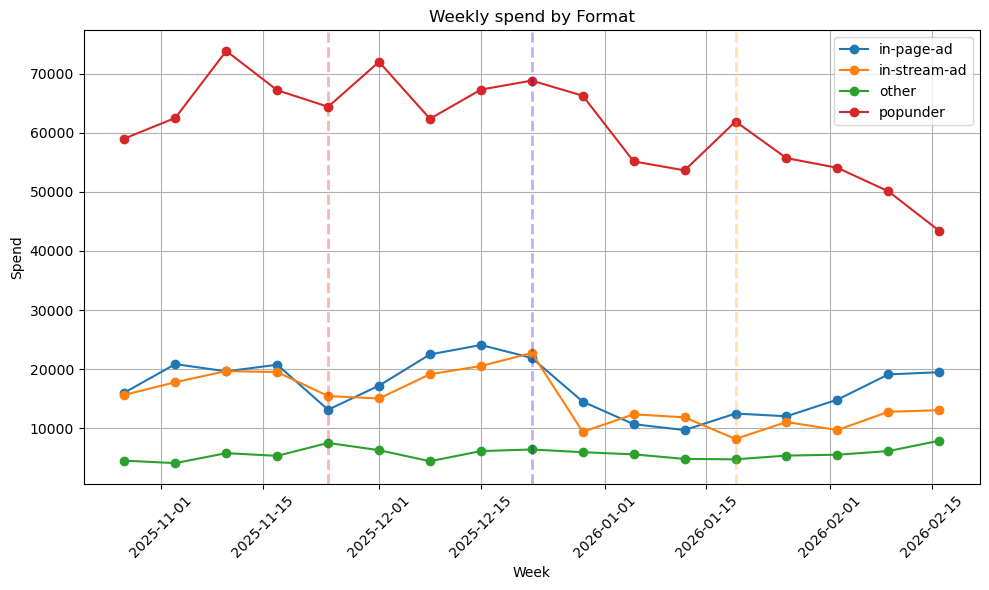

In [166]:
plt.figure(figsize=(10, 6))

for col in df_plot_spend.columns:
    plt.plot(df_plot_spend.index, df_plot_spend[col], marker='o', label=col)

plt.title('Weekly spend by Format')
plt.xlabel('Week')
plt.ylabel('Spend')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.axvline(pd.to_datetime('2025-11-24'),
            linestyle='--',
            linewidth=2, color='red', alpha=0.3)
plt.axvline(pd.to_datetime('2025-12-22'),
            linestyle='--',
            linewidth=2, color='blue', alpha=0.3)
plt.axvline(pd.to_datetime('2026-01-19'),
            linestyle='--',
            linewidth=2, color='orange', alpha=0.3)
plt.show()

Пунктиром на графике обазначены даты выкатки фичи на разных форматах.

По графику динамики спенда видно :
- на попандере : еще месяц после выкатки спенд находится на приемлимом уровне, лишь затем начинает планомерно снижатся после предновогодней недели
- на инпейдже : резкий обвал сразу после выкатки фичи, затем постепенное восстановление к базовому уровню (при том что кол-во кампаний с фичей растёт)
- ни видео - обвал спенда по датам не может быть связан с фичей, скорее после выкатки спенд имеет тенденцию к увеличению, однако до базового уровня еще далековато

Какие из этого могут быть предварительные выводы : 
- на попандере выкатка не связана по времени с падением спенда
- на инпейдже обвал произошёл прямо в неделю выкатки, однако на видео формате обвал произошёл в ту же неделю, хотя смарт еще не будет запущен целый месяц. Учитывая тендецию к восстановлению к базовым уровням, здесь просадка может быть объяснена сезонностью (как и на попандере) и пользовательским оттоком

### Выборка юзеров для анализа, их спенд за период

In [176]:
query = '''
SELECT
    c.user_id,
SUM(cs.cost) / 10000 AS sum_spend
FROM campaigns c
JOIN campaign_statistics cs ON cs.campaign_id = c.id
JOIN users u ON u.id = c.user_id AND u.email NOT LIKE '%%onlinesup%%'
WHERE cs.cost > 0
  AND cs.date >= '2025-11-24'
  AND cs.date <  '2026-02-23'
  AND u.id NOT IN (SELECT DISTINCT user_id FROM networks)
GROUP BY c.user_id
'''

In [177]:
users_data = pd.read_sql(query, engine)

### Спенд по фиче для сегментации по уровню "вовлеченности"

In [184]:
query_on = f'''
WITH
params AS (
  SELECT
    TIMESTAMP('2025-11-24 00:00:00') AS dt_from,
    TIMESTAMP('2026-02-22 23:59:59') AS dt_to
),
events AS (
  SELECT
    a.auditable_id AS campaign_id,
    a.created_at,
    CASE
      WHEN JSON_EXTRACT(a.new_values, '$.smart_bidding') IS NULL THEN NULL
      WHEN JSON_UNQUOTE(JSON_EXTRACT(a.new_values, '$.smart_bidding')) IN ('true','1') THEN 1
      WHEN JSON_UNQUOTE(JSON_EXTRACT(a.new_values, '$.smart_bidding')) IN ('false','0') THEN 0
      ELSE NULL
    END AS new_status
  FROM audits a
  WHERE a.auditable_type LIKE '%%Campaign'
    AND a.event != 'deleted'
    AND (
      JSON_EXTRACT(a.new_values, '$.smart_bidding') IS NOT NULL
      OR JSON_EXTRACT(a.old_values, '$.smart_bidding') IS NOT NULL
    )
),
events_clean AS (
  SELECT
    e.campaign_id,
    e.created_at,
    e.new_status,
    LEAD(e.created_at) OVER (PARTITION BY e.campaign_id ORDER BY e.created_at) AS next_created_at
  FROM events e
  WHERE e.new_status IS NOT NULL
),
on_intervals AS (
  SELECT
    ec.campaign_id,
    GREATEST(ec.created_at, p.dt_from) AS on_start,
    LEAST(COALESCE(ec.next_created_at, p.dt_to), p.dt_to) AS on_end
  FROM events_clean ec
  CROSS JOIN params p
  WHERE ec.new_status = 1
),
on_intervals_valid AS (
  SELECT *
  FROM on_intervals
  WHERE on_start < on_end
)
SELECT
  c.user_id,
  SUM(cs.cost/10000) AS spend
FROM campaign_statistics cs
JOIN campaigns c ON c.id = cs.campaign_id
JOIN users u ON u.id = c.user_id
CROSS JOIN params p
WHERE cs.cost > 0
          AND u.id NOT IN (SELECT DISTINCT user_id FROM networks)
  AND cs.date >= p.dt_from
  AND cs.date <= p.dt_to
  AND EXISTS (
    SELECT 1
    FROM on_intervals_valid i
    WHERE i.campaign_id = cs.campaign_id
      AND cs.date >= i.on_start
      AND cs.date <  i.on_end
  )
GROUP BY c.user_id
'''

In [185]:
spend_on_feature = pd.read_sql(query_on, engine)

In [189]:
feature_spend = users_data[['user_id', 'sum_spend']].merge(spend_on_feature, how ='left', on='user_id').fillna(0)

In [190]:
feature_spend['feature_spend_percent'] = feature_spend['spend'] / feature_spend['sum_spend']

In [192]:
round(feature_spend['spend'].sum() / feature_spend['sum_spend'].sum(), 2)

0.17

Доля фичи в спенде с 24 Ноября по 23 Февраля - 17%

In [197]:
feature_spend.query('feature_spend_percent > 0')['feature_spend_percent'].describe()

count    241.000000
mean       0.458337
std        0.366692
min        0.000004
25%        0.115295
50%        0.377979
75%        0.840785
max        1.000000
Name: feature_spend_percent, dtype: float64

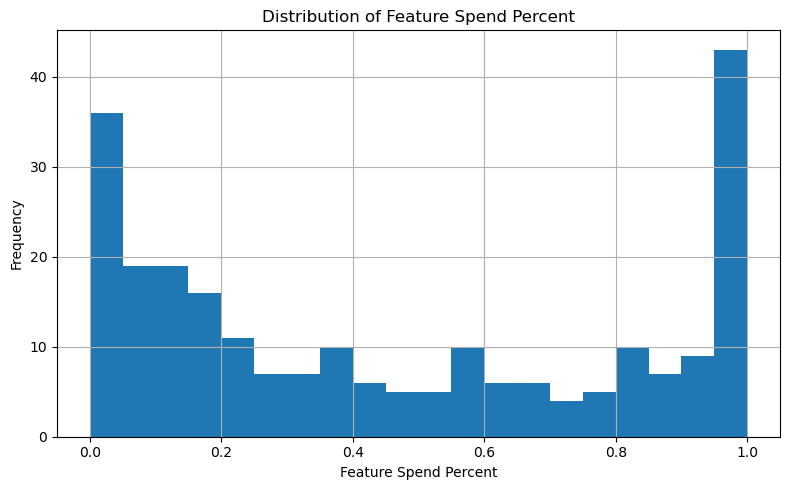

In [200]:
plt.figure(figsize=(8, 5))
plt.hist(feature_spend.query('feature_spend_percent > 0')['feature_spend_percent'], bins=20)
plt.title('Distribution of Feature Spend Percent')
plt.xlabel('Feature Spend Percent')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

Медиана распределения спеднда на фичу составляет 37,8%, среднее - 45,8%. Так же визуально распределение довольно симметричное (в плане смещенных к краям хвостов)

Можно говорить о том, что наша граница в 50% для heavy smart users лишь немного перевешивает среднее значение. Исходя из бизнес логики считаю её допустимой (мы хотим поймать больше изменений по смарту, так же у Лео % спенда по фиче - 58%)

#### Сегментируем юзеров для анализа

##### По доле смарт

In [202]:
feature_spend['feature_spend_used'] = np.select(
    [
        feature_spend['feature_spend_percent'] > 0.5,
        feature_spend['feature_spend_percent'].between(0.05, 0.5, inclusive='both'),
        feature_spend['feature_spend_percent'] < 0.05
    ],
    ['heavy', 'light', 'non'],
    default=np.nan
)

In [205]:
feature_spend['feature_spend_used'].value_counts()

feature_spend_used
non      947
heavy    105
light    100
Name: count, dtype: int64

In [315]:
feature_spend

,user_id,sum_spend,spend,feature_spend_percent,feature_spend_used
0,598,428.7205,0.0000,0.000000,non
1,16721,130078.2531,76293.6064,0.586521,heavy
2,1805,205.1516,0.0000,0.000000,non
3,15132,6361.7199,0.0000,0.000000,non
4,10378,1129.1035,0.0000,0.000000,non
...,...,...,...,...,...
1147,220589,140.1438,0.0000,0.000000,non
1148,220801,2.3706,0.0000,0.000000,non
1149,201055,35.7492,0.0000,0.000000,non
1150,220943,17.2710,0.0000,0.000000,non


Из выборки в 1152 пользователя со спендом в периоде имеем около 10% heavy users и столько же light, подавляющее большинство - не активных

Доли в спенде

In [211]:
feature_spend.groupby('feature_spend_used')['sum_spend'].sum()

feature_spend_used
heavy    215382.3024
light    304625.6670
non      725051.0338
Name: sum_spend, dtype: float64

В деньгах за период активности фичи распределение следующее - около 17% спенда приходится на "тяжелую группу" (мы уже рассчитали ранее), 25% на лёгкую группу, и остальные 58% на тех, кто фичу не юзает

##### По доле инхаус/реселл

Разметка по системам

In [214]:
system_info = pd.read_csv('systems.csv')

In [217]:
system_info.head()

,system_id,system_info
0,1,resell
1,2,resell
2,4,resell
3,5,resell
4,6,resell


In [218]:
system_info['system_info'].value_counts()

system_info
resell     901
inhouse     87
Name: count, dtype: int64

Запрос для разметки по системам

In [244]:
query_v = '''
select clickadilla_user_id as user_id, tcb_system_id as system_id,
sumMerge(revenue) as revenue
from visitstats.clickadilla_traffic_agr
where stats_day >= '2025-11-24' AND stats_day < '2026-02-23'
group by clickadilla_user_id, tcb_system_id
'''

In [245]:
users_systems = client.query_df(query_v)

In [225]:
users_db = users_data['user_id'].to_list()

In [228]:
ch_data = users_systems.query('user_id in @users_db')

In [231]:
ch_data['user_id'].nunique()

1152

In [232]:
ch_data['revenue'].sum()

1246363.4318532934

In [233]:
users_data['sum_spend'].sum()

1245059.0032

Данные по спенду корректны, проверим ошибки в записи систем

In [240]:
anomal_system = list(set(ch_data['system_id'].to_list()) - set(system_info['system_id'].to_list()))

In [241]:
print('Аномальные записи в деньгах')
ch_data.query('system_id in @anomal_system').agg({'revenue':'sum'}).round(2)

Аномальные записи в деньгах


revenue    979.97
dtype: float64

1000$ потерь при маштабе в миллион долларов не критичные потери - удалим

In [242]:
ch_data = ch_data.query('system_id not in @anomal_system')

Теперь разметим

In [247]:
ch_data = ch_data.merge(system_info[['system_id', 'system_info']], on = 'system_id', how = 'left')

In [251]:
agg_ch = ch_data.pivot_table(
    index='user_id', columns='system_info', values='revenue', aggfunc='sum').reset_index().fillna(0)

In [253]:
agg_ch['sum_spend'] = agg_ch['inhouse'] + agg_ch['resell']

In [254]:
agg_ch['inhouse_share'] = agg_ch['inhouse'] / agg_ch['sum_spend']

In [255]:
agg_ch['resell_share'] = agg_ch['resell'] / agg_ch['sum_spend']

In [256]:
agg_ch

system_info,user_id,inhouse,resell,sum_spend,inhouse_share,resell_share
0,44,1106.650000,0.000000,1106.650000,1.000000,0.000000
1,49,3.267600,0.000000,3.267600,1.000000,0.000000
2,101,0.000000,3.758800,3.758800,0.000000,1.000000
3,258,0.535700,0.359150,0.894850,0.598648,0.401352
4,308,3115.832959,443.260198,3559.093157,0.875457,0.124543
...,...,...,...,...,...,...
1146,220676,132.856346,92.795220,225.651566,0.588768,0.411232
1147,220681,6.870960,42.185980,49.056940,0.140061,0.859939
1148,220691,71.885000,0.000000,71.885000,1.000000,0.000000
1149,220801,2.370892,0.000000,2.370892,1.000000,0.000000


In [257]:
agg_ch['inhouse_group'] = np.select(
    [
        agg_ch['inhouse_share'] > 0.6,
        agg_ch['inhouse_share'].between(0.3, 0.6, inclusive='both'),
        agg_ch['inhouse_share'] < 0.3
    ],
    ['high', 'mixed', 'low'],
    default=np.nan
)

In [258]:
agg_ch['inhouse_group'].value_counts()

inhouse_group
high     640
low      291
mixed    220
Name: count, dtype: int64

Подавляющее число юзеров ожидаемо имеют высокую долю инхауса, посмотрим их вес в спенде

In [259]:
agg_ch.groupby('inhouse_group')['sum_spend'].sum()

inhouse_group
high     637995.448732
low      137140.446318
mixed    470247.565220
Name: sum_spend, dtype: float64

В спенде соотношение так же в пользу юзеров с высокой долей инхауса. Интересно что при большей численноти "низкой" группы по инхаусы, спенда она генерирует в 3 раза меньше чем "средняя" группа

Разметка готова, выгрузим данные по user*week для изучения динамики

### Понедельная статистика юзеров по инхаусу/реселу

Маппим списки для запроса

In [260]:
resell_ids = system_info.loc[system_info["system_info"] == "resell", "system_id"].astype(int).tolist()
inhouse_ids = system_info.loc[system_info["system_info"] == "inhouse", "system_id"].astype(int).tolist()

Тестовый запрос

In [262]:
user_id_test = 308

resell_tuple  = tuple(resell_ids)
inhouse_tuple = tuple(inhouse_ids)

In [267]:
query_2 = f"""
SELECT
    clickadilla_user_id AS user_id,
    toStartOfWeek(stats_day, 1) AS week_start,   -- понедельник

    CASE
        WHEN tcb_system_id IN {inhouse_tuple} THEN 'inhouse'
        WHEN tcb_system_id IN {resell_tuple}  THEN 'resell'
        ELSE 'unknown'
    END AS traffic_type,

    sumMerge(revenue)        AS revenue,
    countMerge(impressions)  AS shows,

    concat(
        toString(toISOYear(week_start)), '-W', lpad(toString(toISOWeek(week_start)), 2, '0'),
        ' (', formatDateTime(week_start, '%m-%d'), ')'
    ) AS week_label
FROM visitstats.clickadilla_traffic_agr
WHERE stats_day >= toDate('2025-11-24')
  AND stats_day <  toDate('2026-02-23')
  AND clickadilla_user_id = {user_id_test}
  AND (tcb_system_id IN {inhouse_tuple} OR tcb_system_id IN {resell_tuple})
GROUP BY
    user_id,
    week_start,
    traffic_type
HAVING revenue > 0
ORDER BY
    user_id,
    week_start,
    traffic_type
"""

In [268]:
test_data = client.query_df(query_2)

In [279]:
test_data.head()

,user_id,week_start,traffic_type,revenue,shows,week_label
0,308,2025-11-24,inhouse,327.577551,1606696,2025-W48 (11-24)
1,308,2025-11-24,resell,25.917524,228431,2025-W48 (11-24)
2,308,2025-12-01,inhouse,315.422960,1333381,2025-W49 (12-01)
3,308,2025-12-01,resell,21.302462,215575,2025-W49 (12-01)
4,308,2025-12-08,inhouse,333.358977,1661353,2025-W50 (12-08)


Схлопнем всё в одну строку

In [286]:
query_3 = f'''
SELECT
    clickadilla_user_id AS user_id,
    toStartOfWeek(stats_day, 1) AS week_start,   -- понедельник
    toISOWeek(week_start)  AS iso_week,
    sumMerge(revenue)        AS sum_revenue,
    sumMergeIf(revenue,       tcb_system_id IN {inhouse_tuple}) AS revenue_inhouse,
    sumMergeIf(revenue,       tcb_system_id IN {resell_tuple})  AS revenue_resell,
countMerge(impressions)  AS sum_shows,
    countMergeIf(impressions, tcb_system_id IN {inhouse_tuple}) AS shows_inhouse,
    countMergeIf(impressions, tcb_system_id IN {resell_tuple})  AS shows_resell,

    concat(
        toString(toISOYear(week_start)), '-W', lpad(toString(toISOWeek(week_start)), 2, '0'),
        ' (', formatDateTime(week_start, '%m-%d'), ')'
    ) AS week_label
FROM visitstats.clickadilla_traffic_agr
WHERE stats_day >= toDate('2025-11-24')
  AND stats_day <  toDate('2026-02-23')
  AND clickadilla_user_id = {user_id_test}
  AND (tcb_system_id IN {inhouse_tuple} OR tcb_system_id IN {resell_tuple})   -- системы вне списков отрезаем
GROUP BY
    user_id,
    week_start
ORDER BY
    user_id,
    week_start
'''

In [287]:
test_data_2 = client.query_df(query_3)

In [301]:
test_data_2

,user_id,week_start,iso_week,sum_revenue,revenue_inhouse,revenue_resell,sum_shows,shows_inhouse,shows_resell,week_label
0,308,2025-11-24,48,353.495075,327.577551,25.917524,1835127,1606696,228431,2025-W48 (11-24)
1,308,2025-12-01,49,336.725422,315.422960,21.302462,1548956,1333381,215575,2025-W49 (12-01)
2,308,2025-12-08,50,354.768593,333.358977,21.409616,1881060,1661353,219707,2025-W50 (12-08)
3,308,2025-12-15,51,301.508241,278.590969,22.917273,1657397,1473556,183841,2025-W51 (12-15)
4,308,2025-12-22,52,324.422708,297.310878,27.111830,1539016,1336375,202641,2025-W52 (12-22)
5,308,2025-12-29,1,318.711240,282.317718,36.393522,1693208,1447980,245228,2026-W01 (12-29)
6,308,2026-01-05,2,399.950926,353.342579,46.608346,1920179,1648975,271204,2026-W02 (01-05)
7,308,2026-01-12,3,322.789283,274.836499,47.952784,1290624,1045963,244661,2026-W03 (01-12)
8,308,2026-01-19,4,215.159159,171.378059,43.781099,720963,538714,182249,2026-W04 (01-19)
9,308,2026-01-26,5,190.298426,164.409972,25.888454,711873,622423,89450,2026-W05 (01-26)


Формат корректный. Теперь выгрузим все данные, плюс для списка наших юзеров добавим базовый период (месяц до выкатки)

In [290]:
query_ch_stats = f'''
SELECT
    clickadilla_user_id AS user_id,
    toStartOfWeek(stats_day, 1) AS week_start,
    toISOWeek(week_start)  AS iso_week,
    sumMerge(revenue)        AS sum_revenue,
    sumMergeIf(revenue,       tcb_system_id IN {inhouse_tuple}) AS revenue_inhouse,
    sumMergeIf(revenue,       tcb_system_id IN {resell_tuple})  AS revenue_resell,
countMerge(impressions)  AS sum_shows,
    countMergeIf(impressions, tcb_system_id IN {inhouse_tuple}) AS shows_inhouse,
    countMergeIf(impressions, tcb_system_id IN {resell_tuple})  AS shows_resell,

    concat(
        toString(toISOYear(week_start)), '-W', lpad(toString(toISOWeek(week_start)), 2, '0'),
        ' (', formatDateTime(week_start, '%m-%d'), ')'
    ) AS week_label
FROM visitstats.clickadilla_traffic_agr
WHERE stats_day >= toDate('2025-10-27')
  AND stats_day <  toDate('2026-02-23')
  AND clickadilla_user_id IN {users_db}
  AND (tcb_system_id IN {inhouse_tuple} OR tcb_system_id IN {resell_tuple})
GROUP BY
    user_id,
    week_start
ORDER BY
    user_id,
    week_start
'''

In [291]:
traffic_stats = client.query_df(query_ch_stats)

In [292]:
traffic_stats.head()

,user_id,week_start,iso_week,sum_revenue,revenue_inhouse,revenue_resell,sum_shows,shows_inhouse,shows_resell,week_label
0,44,2025-11-03,45,1271.46668,1271.46668,0.0,394866,394866,0,2025-W45 (11-03)
1,44,2025-11-10,46,1219.91676,1219.91676,0.0,404243,404243,0,2025-W46 (11-10)
2,44,2025-11-17,47,1400.70330,1400.70330,0.0,518779,518779,0,2025-W47 (11-17)
3,44,2025-11-24,48,299.98890,299.98890,0.0,110637,110637,0,2025-W48 (11-24)
4,44,2025-12-01,49,182.06490,182.06490,0.0,62781,62781,0,2025-W49 (12-01)


In [293]:
traffic_stats['user_id'].nunique()

1151

Один юзер потерялся, для исследования не критично

In [299]:
traffic_stats.query('iso_week > 47 or iso_week < 9')['sum_revenue'].sum().round()

1245383.0

In [300]:
users_data['sum_spend'].sum().round()

1245059.0

По спенду данные корректны

Теперь добавим статистику по использованию смартбиддинга по неделям

### Понедельная статистика юзеров по смартбиду

Так как у нас задействовано 3 формата, и выкатки происходили в разное время, не делаем разделения по каждому формату отдельно, как бы схлопываю фичу в одну

Здесь даты оставляем на момент старта фичи

In [304]:
query_ft = f'''
WITH
params AS (
  SELECT
    TIMESTAMP('2025-11-24 00:00:00') AS dt_from,
    TIMESTAMP('2026-02-22 23:59:59') AS dt_to
),
events AS (
  SELECT
    a.auditable_id AS campaign_id,
    a.created_at,
    CASE
      WHEN JSON_EXTRACT(a.new_values, '$.smart_bidding') IS NULL THEN NULL
      WHEN JSON_UNQUOTE(JSON_EXTRACT(a.new_values, '$.smart_bidding')) IN ('true','1') THEN 1
      WHEN JSON_UNQUOTE(JSON_EXTRACT(a.new_values, '$.smart_bidding')) IN ('false','0') THEN 0
      ELSE NULL
    END AS new_status
  FROM audits a
  WHERE a.auditable_type LIKE '%%Campaign'
    AND a.event != 'deleted'
    AND (
      JSON_EXTRACT(a.new_values, '$.smart_bidding') IS NOT NULL
      OR JSON_EXTRACT(a.old_values, '$.smart_bidding') IS NOT NULL
    )
),
events_clean AS (
  SELECT
    e.campaign_id,
    e.created_at,
    e.new_status,
    LEAD(e.created_at) OVER (PARTITION BY e.campaign_id ORDER BY e.created_at) AS next_created_at
  FROM events e
  WHERE e.new_status IS NOT NULL
),
on_intervals AS (
  SELECT
    ec.campaign_id,
    GREATEST(ec.created_at, p.dt_from) AS on_start,
    LEAST(COALESCE(ec.next_created_at, p.dt_to), p.dt_to) AS on_end
  FROM events_clean ec
  CROSS JOIN params p
  WHERE ec.new_status = 1
),
on_intervals_valid AS (
  SELECT *
  FROM on_intervals
  WHERE on_start < on_end
)

SELECT
  c.user_id,

  -- недели в нужном формате
  CONCAT(
      WEEKOFYEAR(cs.date),
      ' (',
      DATE_FORMAT(
          DATE_SUB(cs.date, INTERVAL WEEKDAY(cs.date) DAY),
          '%%m-%%d'
      ),
      ')'
  ) AS week_label,
  WEEKOFYEAR(cs.date) AS week,
  DATE_SUB(DATE(cs.date), INTERVAL WEEKDAY(cs.date) DAY) AS week_start,

  -- spend
  SUM(cs.cost/10000) AS spend_total,

  SUM(
    CASE WHEN EXISTS (
      SELECT 1
      FROM on_intervals_valid i
      WHERE i.campaign_id = cs.campaign_id
        AND cs.date >= i.on_start
        AND cs.date <  i.on_end
    )
    THEN cs.cost/10000 ELSE 0 END
  ) AS spend_feature_on,

  SUM(
    CASE WHEN NOT EXISTS (
      SELECT 1
      FROM on_intervals_valid i
      WHERE i.campaign_id = cs.campaign_id
        AND cs.date >= i.on_start
        AND cs.date <  i.on_end
    )
    THEN cs.cost/10000 ELSE 0 END
  ) AS spend_feature_off,

  -- активные кампании (в рамках недели, т.к. group by week)
  COUNT(DISTINCT CASE WHEN EXISTS (
      SELECT 1
      FROM on_intervals_valid i
      WHERE i.campaign_id = cs.campaign_id
        AND cs.date >= i.on_start
        AND cs.date <  i.on_end
  ) THEN cs.campaign_id END) AS active_campaigns_on,

  COUNT(DISTINCT CASE WHEN NOT EXISTS (
      SELECT 1
      FROM on_intervals_valid i
      WHERE i.campaign_id = cs.campaign_id
        AND cs.date >= i.on_start
        AND cs.date <  i.on_end
  ) THEN cs.campaign_id END) AS active_campaigns_off

FROM campaign_statistics cs
JOIN campaigns c ON c.id = cs.campaign_id
JOIN users u ON u.id = c.user_id
CROSS JOIN params p

WHERE cs.cost > 0
  AND u.id NOT IN (SELECT DISTINCT user_id FROM networks)
  AND cs.date >= p.dt_from
  AND cs.date <= p.dt_to

GROUP BY
  c.user_id,
  week_label,
  week,
  week_start

ORDER BY
  c.user_id,
  week_start
'''

In [310]:
feature_stats = pd.read_sql(query_ft, engine)

In [312]:
feature_stats['user_id'].nunique()

1157

In [314]:
feature_stats['spend_total'].sum()

1247735.6798999999

Чуть больше суммы по людям и спенду, разница не критична, тем более будем объединять данные

### Объединяем статистику

In [327]:
feature_stats['iso_week'] = feature_stats['week']

In [334]:
merge_data = feature_stats[['user_id', 'iso_week', 'spend_feature_on', 'spend_feature_off', 'active_campaigns_on', 'active_campaigns_off']]

In [340]:
df = (traffic_stats
 .merge(feature_spend[['user_id','feature_spend_used']])
.merge(agg_ch[['user_id', 'inhouse_group']])
.merge(merge_data, on=['user_id', 'iso_week'], how='left')
 .rename(columns={'sum_revenue':'spend', 'sum_shows':'shows', 'revenue_inhouse':'spend_inhouse',
        'revenue_resell':'spend_resell', 'feature_spend_used':'smart_group'}))

In [342]:
df.head()

,user_id,week_start,iso_week,spend,spend_inhouse,spend_resell,shows,shows_inhouse,shows_resell,week_label,smart_group,inhouse_group,spend_feature_on,spend_feature_off,active_campaigns_on,active_campaigns_off
0,44,2025-11-03,45,1271.46668,1271.46668,0.0,394866,394866,0,2025-W45 (11-03),non,high,NaN,NaN,NaN,NaN
1,44,2025-11-10,46,1219.91676,1219.91676,0.0,404243,404243,0,2025-W46 (11-10),non,high,NaN,NaN,NaN,NaN
2,44,2025-11-17,47,1400.70330,1400.70330,0.0,518779,518779,0,2025-W47 (11-17),non,high,NaN,NaN,NaN,NaN
3,44,2025-11-24,48,299.98890,299.98890,0.0,110637,110637,0,2025-W48 (11-24),non,high,0.0,299.8188,0.0,1.0
4,44,2025-12-01,49,182.06490,182.06490,0.0,62781,62781,0,2025-W49 (12-01),non,high,0.0,181.8271,0.0,1.0


Данные готовы и проверены, можем переходить к анализу

# Анализ и проверка гипотез

Для начала добавим доли по инхаусу + смарту, а так же рассчитаем CPM

In [344]:
df['inhouse_share'] = df['spend_inhouse'] / df['spend']

In [345]:
df['smart_share'] = df['spend_feature_on'] / df['spend']

In [346]:
df['inhouse_share'].describe()

count    7003.000000
mean        0.649750
std         0.386865
min         0.000000
25%         0.272921
50%         0.835530
75%         1.000000
max         1.000000
Name: inhouse_share, dtype: float64

In [347]:
df['smart_share'].describe()

count    5027.000000
mean        0.099050
std         0.278091
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.018525
Name: smart_share, dtype: float64

Здесь из-за разности источников видим доли чуть больше 100% - приравняем к 100

In [350]:
df['smart_share'] = df['smart_share'].clip(upper=1)

In [363]:
df['smart_share'].describe()

count    5027.000000
mean        0.099024
std         0.278006
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: smart_share, dtype: float64

In [360]:
df['cpm'] = np.where(
    df['shows'] > 0,
    df['spend'] / (df['shows'] / 1000),
    np.nan
)

In [361]:
df['cpm'].describe()

count    7312.000000
mean        0.823221
std         5.985941
min         0.000000
25%         0.020173
50%         0.188881
75%         0.720000
max       270.000000
Name: cpm, dtype: float64

Видим аномальные значения, уберём их при анализе

## Churn rate по группам

_H4 - Изменения (в спенде) не объясняются только пользовательским оттоком._

### Подготовка данных

In [368]:
df['week_start'] = pd.to_datetime(df['week_start'])

In [369]:
df = df.sort_values(['user_id', 'week_start']).reset_index(drop=True)

In [372]:
df['prev_week_start'] = df.groupby('user_id')['week_start'].shift(1)

In [373]:
df['gap_days'] = (df['week_start'] - df['prev_week_start']).dt.days

In [374]:
df['gap_days']

0       NaN
1       7.0
2       7.0
3       7.0
4       7.0
       ... 
7532    NaN
7533    NaN
7534    NaN
7535    NaN
7536    NaN
Name: gap_days, Length: 7537, dtype: float64

Достаточно ли времени наблюдения у юзера (так как у нас есть "свежие" юзеры)

In [375]:
data_end = df['week_start'].max()

In [377]:
user_first_week = df.groupby('user_id')['week_start'].transform('min')

сколько недель от первой недели юзера до конца датасета

In [378]:
df['weeks_observed_from_first'] = ((data_end - user_first_week).dt.days // 7)

In [382]:
df['eligible_for_churn'] = df['weeks_observed_from_first'] >= 2

In [390]:
df['gap_event'] = (df['gap_days'] >= 21)

Исключаем из определения юзеров, которые только "пришли"

In [391]:
df.loc[~df['eligible_for_churn'], 'gap_event'] = False

Исключим случаи где была статистика после гапа

In [393]:
user_last_week = df.groupby('user_id')['week_start'].transform('max')

In [394]:
df['is_last_row_for_user'] = df['week_start'].eq(user_last_week)

Churn = 1, если после последней недели пользователя до конца датасета прошло ≥ 2 недель без записей.

In [395]:
df['weeks_silent_to_end'] = ((data_end - user_last_week).dt.days // 7)

In [396]:
df['churn_user'] = (
    df['eligible_for_churn'] &
    (df['weeks_silent_to_end'] >= 2)
)

In [403]:
df['churn'] = (
    df['eligible_for_churn'] &
    (df['weeks_silent_to_end'] >= 2)
).astype(int)

In [404]:
df[['user_id','churn']].drop_duplicates()['churn'].value_counts()

churn
1    589
0    562
Name: count, dtype: int64

Видим отток в районе 50%

Удалим лишние колонки

In [405]:
df.columns

Index(['user_id', 'week_start', 'iso_week', 'spend', 'spend_inhouse',
       'spend_resell', 'shows', 'shows_inhouse', 'shows_resell', 'week_label',
       'smart_group', 'inhouse_group', 'spend_feature_on', 'spend_feature_off',
       'active_campaigns_on', 'active_campaigns_off', 'inhouse_share',
       'smart_share', 'cpm', 'prev_week_start', 'gap_days',
       'weeks_observed_from_first', 'eligible_for_churn', 'gap_event',
       'is_last_row_for_user', 'weeks_silent_to_end', 'churn_user', 'churn'],
      dtype='object')

In [406]:
cols_to_drop = [
    'prev_week_start',
    'gap_days',
    'gap_event',
    'weeks_observed_from_first',
    'eligible_for_churn',
    'weeks_silent_to_end',
    'is_last_row_for_user',
    'churn_user'
]

In [407]:
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [409]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype        
---  ------                --------------  -----        
 0   user_id               7537 non-null   int32        
 1   week_start            7537 non-null   datetime64[s]
 2   iso_week              7537 non-null   uint8        
 3   spend                 7537 non-null   float64      
 4   spend_inhouse         7537 non-null   float64      
 5   spend_resell          7537 non-null   float64      
 6   shows                 7537 non-null   uint64       
 7   shows_inhouse         7537 non-null   uint64       
 8   shows_resell          7537 non-null   uint64       
 9   week_label            7537 non-null   string       
 10  smart_group           7537 non-null   object       
 11  inhouse_group         7537 non-null   object       
 12  spend_feature_on      5027 non-null   float64      
 13  spend_feature_off     5027 non-nu

Пожалуй еще некоторые колонки можно удалить, пока оставим, вдруг понадобятся

### Churn по группам смарта

In [418]:
print('Отток на платформе')
df.drop_duplicates(subset=['user_id'])['churn'].mean().round(3)

Отток на платформе


0.512

In [427]:
print('Отток по групам смарта')
(df.drop_duplicates(subset=['user_id'])
.groupby('smart_group', as_index=False)
.agg({'user_id':'nunique', 'churn':'mean'})).rename(columns={'user_id':'count_users'}).round(2)

Отток по групам смарта


,smart_group,count_users,churn
0,heavy,105,0.45
1,light,100,0.28
2,non,946,0.54


Отток в группе смарта 45%, это ниже среднего значения, и ниже группы без смарта. Интересно что лайт группа по смарту показывает самый низкий отток 

### Churn по inhouse сегментам

In [429]:
(df.drop_duplicates(subset=['user_id'])
.groupby('inhouse_group', as_index=False)
.agg({'user_id':'nunique', 'churn':'mean'})).rename(columns={'user_id':'count_users'}).round(2)

,inhouse_group,count_users,churn
0,high,640,0.46
1,low,291,0.66
2,mixed,220,0.47


Самый высокий отток (66%) в группе с низкой долей инхауса. Для лайт и высокой групп инхауса отток равен 46-47%, это чутьниже среднего значения

### Понедельная динамика оттока 

Общий отток и по группам

In [430]:
weekly_total = (
    df.groupby('week_start')['churn']
      .mean()
      .reset_index(name='churn_total')
)

In [432]:
weekly_group = (
    df.groupby(['week_start', 'smart_group'])['churn']
      .mean()
      .reset_index()
)

Объединим

In [433]:
weekly_group_pivot = weekly_group.pivot(
    index='week_start',
    columns='smart_group',
    values='churn'
).reset_index()

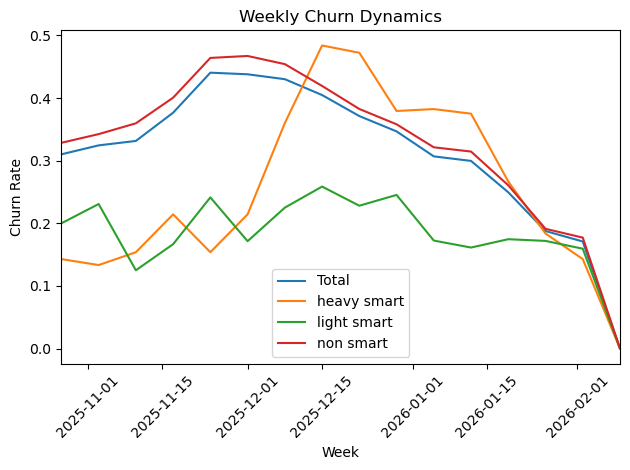

In [438]:
plt.figure()

# линия Total
plt.plot(
    weekly_total['week_start'],
    weekly_total['churn_total'],
    label='Total'
)

# линии по smart_group
for col in weekly_group_pivot.columns:
    if col != 'week_start':
        plt.plot(
            weekly_group_pivot['week_start'],
            weekly_group_pivot[col],
            label=f'{col} smart'
        )

plt.xlabel('Week')
plt.ylabel('Churn Rate')
plt.title('Weekly Churn Dynamics')
plt.legend()
plt.xticks(rotation=45)
max_week = df['week_start'].max()
cutoff_week = max_week - pd.Timedelta(weeks=1)
plt.xlim(df['week_start'].min(), cutoff_week)
plt.tight_layout()
plt.show()

Из этого графика можно сделать вывод, что пик оттока приходится на даты 24.11 - 22.12 (во всех группах кроме лайт, которая самая лояльная). Отчасти этим объясняется большая просадка спенда в Январе.

Так же мы видим почти идентичные линии тотал оттока и нон смарт группы - это говорит о малом влиянии смарт групп на общий отток

### Вывод

Как среди юзеров, использующих смарт, так и получающих инхаус - средний отток ниже альтернативных групп.

Это аргумент в пользу гипотезы о том, что просадка в спенде обусловлена оттоком, а не внедрением фичи. 

Как кажется фича скорее позитивно повлияла удержание юзеров, но здесь важно не путать причину и следствие (не ясно, фича сделала юзеров более лояльными - или это более лояьлные юзеры выбрали фичу)

## Распределение Δ inhouse spend по группам смарта

_H1 Пользователи с высокой долей Smart Bidding снизили inhouse spend относительно своего исторического baseline_

_H2 Снижение inhouse spend у heavy Smart пользователей сильнее, чем у пользователей без Smart_

Здесь будем отдельно рассматривать группу churn vs retained

In [440]:
churn = df.query('churn == 1')

In [441]:
retained = df.query('churn == 0')

Для начала взглянем на общую картину по инхаус спенду

In [445]:
weekly_spend = (
    df.groupby('week_start')[['spend_inhouse', 'spend_resell']]
      .sum()
      .reset_index()
)

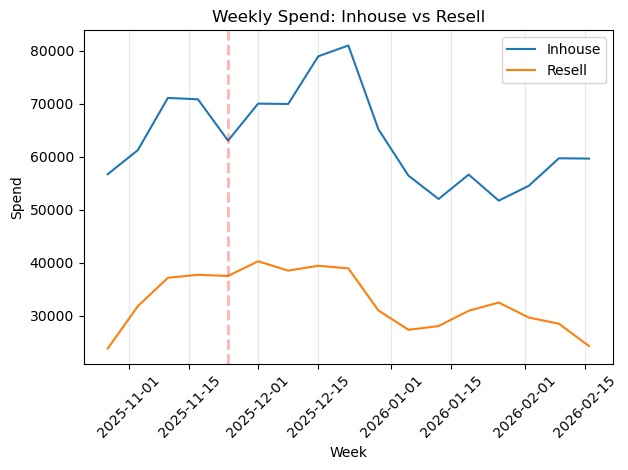

In [465]:
plt.figure()

plt.plot(
    weekly_spend['week_start'],
    weekly_spend['spend_inhouse'],
    label='Inhouse'
)

plt.plot(
    weekly_spend['week_start'],
    weekly_spend['spend_resell'],
    label='Resell'
)

plt.xlabel('Week')
plt.ylabel('Spend')
plt.title('Weekly Spend: Inhouse vs Resell')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='x', alpha=0.3)
plt.axvline(pd.to_datetime('2025-11-24'),
            linestyle='--',
            linewidth=2, color='red', alpha=0.3)
plt.tight_layout()
plt.show()

Видим рост Ноября-Декабря и сильную просадку в Январе по обоим типам трафика.

В феврале по инхаусу видим небольшой отскок

In [481]:
df['period'] = df['week_start'].apply(
    lambda x: 'after' if x >= pd.Timestamp('2025-11-24') else 'before'
)

In [552]:
df['pseudo_period'] = df['week_start'].apply(
    lambda x: 'after' if x > pd.Timestamp('2025-12-29') else 'before'
)

In [489]:
weekly = (
    df.groupby(['week_start', 'period'], as_index=False)[['spend_inhouse', 'spend_resell']]
      .sum()
)

In [500]:
print('Средненедельный спенд по периодам')
(weekly.groupby('period', as_index=False)[['spend_inhouse', 'spend_resell']]
          .mean()).reset_index().round().T[1:]

Средненедельный спенд по периодам


,0,1
period,after,before
spend_inhouse,62996.0,64985.0
spend_resell,32803.0,32583.0


Если водораздел проводить по дате старта фичи на попандере, то мы видим что средненедельный спенд Декабря - Января немного ниже значений Ноября - падение 2000 на инхаусе (при росте 200 на реселе), то есть мы наблюдаем падение на 1800 в неделю (около 250 дейли) - или 2.7%

### H1 Пользователи с высокой долей Smart Bidding снизили inhouse spend относительно своего исторического baseline

In [557]:
df_heavy = df[df['smart_group'] == 'heavy'].copy()

In [454]:
weekly_heavy = (
    df_heavy
    .groupby(['week_start', 'churn'])['spend_inhouse']
    .sum()
    .reset_index()
)

In [455]:
weekly_heavy_pivot = weekly_heavy.pivot(
    index='week_start',
    columns='churn',
    values='spend_inhouse'
).reset_index()

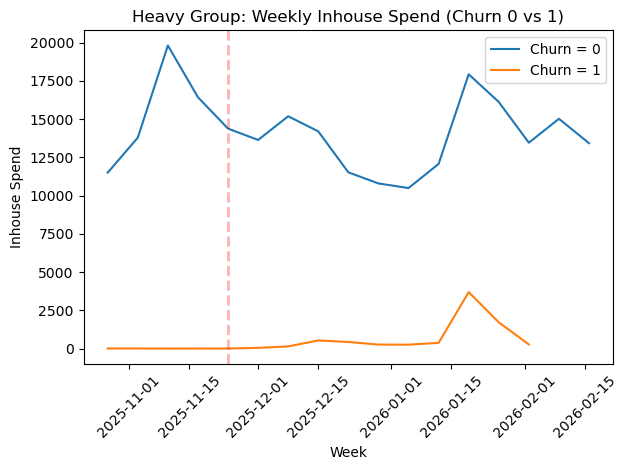

In [458]:
plt.figure()

if 0 in weekly_heavy_pivot.columns:
    plt.plot(
        weekly_heavy_pivot['week_start'],
        weekly_heavy_pivot[0],
        label='Churn = 0'
    )

if 1 in weekly_heavy_pivot.columns:
    plt.plot(
        weekly_heavy_pivot['week_start'],
        weekly_heavy_pivot[1],
        label='Churn = 1'
    )

plt.xlabel('Week')
plt.ylabel('Inhouse Spend')
plt.title('Heavy Group: Weekly Inhouse Spend (Churn 0 vs 1)')
plt.legend()
plt.xticks(rotation=45)
plt.axvline(pd.to_datetime('2025-11-24'),
            linestyle='--',
            linewidth=2, color='red', alpha=0.3)
plt.tight_layout()
plt.show()

Деление на отток почти бессмысленно, так как для отточной групы видим очень маленькие значения.

Визуально до фичи средний спенд был выше, проверим математически (деление по оттоку проводить не будем)

In [504]:
weekly_heavy = (
    df_heavy.groupby(['week_start', 'period'], as_index=False)[['spend_inhouse', 'spend_resell']]
      .sum()
)

In [505]:
print('Средненедельный спенд по периодам для группы heavy smart')
(weekly_heavy.groupby('period', as_index=False)[['spend_inhouse', 'spend_resell']]
          .mean()).reset_index().round().T[1:]

Средненедельный спенд по периодам для группы heavy smart


,0,1
period,after,before
spend_inhouse,14312.0,15396.0
spend_resell,2262.0,2454.0


По обоим типам трафика наблюдаем небольшое падение (в целом 7%)

### H2 Снижение inhouse spend у heavy Smart пользователей сильнее, чем у пользователей без Smart

In [558]:
df_non = df[df['smart_group'] == 'non'].copy()

In [508]:
weekly_non = (
    df_non.groupby(['week_start', 'period'], as_index=False)[['spend_inhouse', 'spend_resell']]
      .sum()
)

In [510]:
print('Средненедельный спенд по периодам для группы non smart')
(weekly_non.groupby('period', as_index=False)[['spend_inhouse', 'spend_resell']]
          .mean()).reset_index().round().T[1:]

Средненедельный спенд по периодам для группы non smart


,0,1
period,after,before
spend_inhouse,35063.0,40851.0
spend_resell,20728.0,25655.0


Здесь падение выше, чем в группе смарт на 9% (или в два раз - в итоге 16%)

То есть пользователи без смарта просели в два раза выше! 

Так как нам важно понять именно просадку после нового года, добавим новый период для анализа (чтобы детальнее изучить фактор сезонности)

### Псевдо-период

In [553]:
weekly_pseudo = (
    df.groupby(['week_start', 'pseudo_period'], as_index=False)[['spend_inhouse', 'spend_resell']]
      .sum()
)

In [554]:
print('Средненедельный спенд по периодам')
(weekly_pseudo.groupby('pseudo_period', as_index=False)[['spend_inhouse', 'spend_resell']]
          .mean()).reset_index().round().T[1:]

Средненедельный спенд по периодам


,0,1
pseudo_period,after,before
spend_inhouse,55811.0,68821.0
spend_resell,28709.0,35581.0


Итак общее падение после Нового года составляет 19% (Ноябрь + Декабрь против Январь + Февраль) - при ожидаемом сезонном падении в 18-21% Января, можно сказать что к Февралю спенд стабилизировался с небольшой просадкой

#### По группам

Смарт группа

In [555]:
weekly_pseudo_heavy = (
    df_heavy.groupby(['week_start', 'pseudo_period'], as_index=False)[['spend_inhouse', 'spend_resell']]
      .sum()
)

In [559]:
print('Средненедельный спенд по периодам')
(weekly_pseudo_heavy.groupby('pseudo_period', as_index=False)[['spend_inhouse', 'spend_resell']]
          .mean()).reset_index().round().T[1:]

Средненедельный спенд по периодам


,0,1
pseudo_period,after,before
spend_inhouse,14493.0,14634.0
spend_resell,2754.0,1909.0


Для группы смарт после НГ наблюдаем небольшой рост в спенде (4%), в основном за счёт увеличения ресела. 

Учитывая просадку при сравнении предыдущих периодов, можно сказать что эта группа просела в основном в Декабре

Без смарта

In [560]:
weekly_pseudo_non = (
    df_non.groupby(['week_start', 'pseudo_period'], as_index=False)[['spend_inhouse', 'spend_resell']]
      .sum()
)

In [561]:
print('Средненедельный спенд по периодам')
(weekly_pseudo_non.groupby('pseudo_period', as_index=False)[['spend_inhouse', 'spend_resell']]
          .mean()).reset_index().round().T[1:]

Средненедельный спенд по периодам


,0,1
pseudo_period,after,before
spend_inhouse,26269.0,43534.0
spend_resell,14771.0,26869.0


Для этой группы нвблюдаем падение в 40%! после НГ

Можно уверенно утверждать, что падения Января обусловлено группой пользователей, не использующих "умную" закупку

### Вывод

Сравнивая данные по спенду юзеров групп heavy vs non smart, мы видим явную просадку второй группы в оба периода "после" относительно первой группы

## Вклад пользователей со смартом в общую просадку

_H3 Вклад heavy Smart пользователей статистически объясняет существенную часть общей просадки выручки._

Рассчитаем какая доля просадки этой группы приходится на общую просадку

агрегируем до недели × группа × период

In [524]:
weekly_smart_group = (
    df.groupby(['week_start','period','smart_group'])['spend']
      .sum()
      .reset_index()
)

считаем средненедельное по периодам

In [526]:
group_period_mean = (
    weekly_smart_group
    .groupby(['smart_group','period'])['spend']
    .mean()
    .reset_index()
)

pivot

In [529]:
group_pivot = group_period_mean.pivot(
    index='smart_group',
    columns='period',
    values='spend'
)

Считаем просадку по группам (дельты)

In [530]:
group_pivot['delta'] = group_pivot['after'] - group_pivot['before']

Считаем общую просадку проекта

In [531]:
total_before = group_pivot['before'].sum()
total_after  = group_pivot['after'].sum()

In [532]:
total_delta = total_after - total_before

Считаем вклад каждой группы

In [533]:
group_pivot['contribution_share'] = (
    group_pivot['delta'] / total_delta
)

In [537]:
print('Просадка по группам')
group_pivot.round(2)

Просадка по группам


period,after,before,delta,contribution_share
smart_group,,,,
heavy,16574.24,17850.41,-1276.17,0.72
light,23433.67,13211.73,10221.94,-5.78
non,55790.82,66505.95,-10715.13,6.06


Посчитаем чистую просадку

In [538]:
negative = group_pivot[group_pivot['delta'] < 0].copy()

In [539]:
negative['drop_share'] = (
    negative['delta'].abs() /
    negative['delta'].abs().sum()
)

In [542]:
negative.round(2)

period,after,before,delta,contribution_share,drop_share
smart_group,,,,,
heavy,16574.24,17850.41,-1276.17,0.72,0.11
non,55790.82,66505.95,-10715.13,6.06,0.89


Общая средненедельная просадка равна 1800 долларов (рассчитано ранее), однако она складывается из большой просадки группы без смарта и компенсацией спенда у "лёгкой" группы. 

То есть произошло перераспределение средств после старта фичи (общее падение почти полностью компенсируется увеличением спенда "легкой" группы смарта)

Если говорить о доле в общем падение двух групп, то падение группы смарта составляет 11% в общей выручке (против 89% падения у группы без смарта)

### Псевдо-период

In [562]:
weekly_smart_group_pseudo = (
    df.groupby(['week_start','pseudo_period','smart_group'])['spend']
      .sum()
      .reset_index()
)

In [563]:
group_period_mean_pseudo = (
    weekly_smart_group_pseudo
    .groupby(['smart_group','pseudo_period'])['spend']
    .mean()
    .reset_index()
)

In [564]:
group_pivot_pseudo = group_period_mean_pseudo.pivot(
    index='smart_group',
    columns='pseudo_period',
    values='spend'
)

In [565]:
group_pivot_pseudo['delta'] = group_pivot_pseudo['after'] - group_pivot_pseudo['before']

In [566]:
total_before_pseudo = group_pivot_pseudo['before'].sum()
total_after_pseudo  = group_pivot_pseudo['after'].sum()

In [567]:
total_delta_pseudo = total_after_pseudo - total_before_pseudo

In [568]:
group_pivot_pseudo['contribution_share'] = (
    group_pivot_pseudo['delta'] / total_delta_pseudo
)

In [569]:
group_pivot_pseudo

pseudo_period,after,before,delta,contribution_share
smart_group,,,,
heavy,17996.297780,16089.264726,1907.033054,-0.095917
light,25483.234662,17910.193792,7573.040870,-0.380896
non,41040.107519,70402.373682,-29362.266163,1.476812


Итак мы видим просадку группы без смарта в 145%, что говорит о том, что группы смарта частично эту просадку компенсировали.

То есть после Нового года просадка средненедельного спенда в группе смарт составляет 0% денег всего проекта (небольшой рост) при 100% просадке группы без смарта.

Напомню, что мы сравниваем средние значения, а не тоталы, так как кол-во недель разное в два периода

### Вывод

В период после Нового Года пользователи со смартом имеют небольшую тенденцию к росту, 100% общей просадки проекта приходится на юзеров, не использующих смарт бидинг

## Общие выводы

Общая просадка Января-Февраля относительно Ноября-Декабря составляет 19%, что нормально с исторической точки зрения. Просадка равномерна как на инхаусе, так и на реселе.

Аномальный Январь объясняется жирным Декабрём + высоким оттоком, в Феврале картина стабилизируется.

Говоря о смарт-биддинге :
- отток с фичей ниже почти в 2 раза
- спенд юзеров со смартом стабилен в оба периода

Просадка проекта на 100% обусловлена юзерами, которые не используют фичу